# POTATO DISEASE CLASSISFICATION

Kaggle Dataset: [click here](https://www.kaggle.com/datasets/arjuntejaswi/plant-village)

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt

In [2]:
import os
import shutil

import kagglehub

# Download latest version
path = kagglehub.dataset_download("arjuntejaswi/plant-village")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'plant-village' dataset.
Path to dataset files: /kaggle/input/plant-village


In [3]:
os.listdir(path)

['PlantVillage']

In [4]:
# SRC_DIR = "/kaggle/input/plant-village/PlantVillage"
SRC_DIR =  '/root/.cache/kagglehub/datasets/arjuntejaswi/plant-village/versions/1/PlantVillage'
DST_DIR = "/content/PlantVillage"

if os.path.exists(DST_DIR):
    shutil.rmtree(DST_DIR)

os.makedirs(DST_DIR, exist_ok=True)


## keep the only the three requireed folders

keep_folders = [
    "Potato___Early_blight",
    "Potato___Late_blight",
    "Potato___healthy"
]

for folder in keep_folders:
    src_path = os.path.join(SRC_DIR, folder)
    dst_path = os.path.join(DST_DIR, folder)
    shutil.copytree(src_path, dst_path)

In [5]:
IMAGE_SIZE = 256
BATCH_SIZE = 32
CHANNELS = 3
EPOCHS = 50

In [6]:
## preprocess the dataset
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "/content/PlantVillage",
    shuffle = True,
    image_size = (IMAGE_SIZE, IMAGE_SIZE),
    batch_size = BATCH_SIZE
)

Found 2152 files belonging to 3 classes.


In [7]:
class_names = dataset.class_names
class_names

['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']

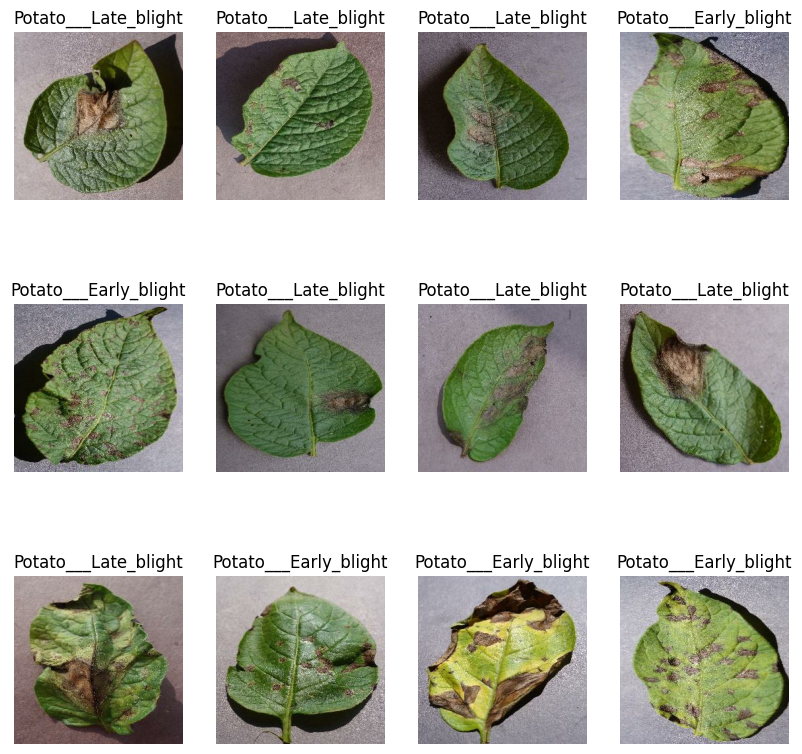

In [8]:
plt.figure(figsize=(10, 10))
for image_batch, label_batch in dataset.take(1):
    for i in range(12):
        ax = plt.subplot(3, 4, i + 1)
        plt.imshow(image_batch[i].numpy().astype("uint8"))
        plt.title(class_names[label_batch[i]])
        plt.axis('off')

### Split dataset Train, Val, Test (80, 10, 10)

In [9]:
len(dataset)

68

In [10]:
# 80% ==> training
# 20% ==> 10% validation, 10% test

In [11]:
train_size = 0.8
len(dataset)*train_size

54.400000000000006

In [12]:
train_ds = dataset.take(54)
len(train_ds)

54

In [13]:
### skip the training set
test_ds = dataset.skip(54)
len(test_ds)

14

In [14]:
val_size = 0.1
len(dataset)*val_size

6.800000000000001

In [15]:
val_ds = test_ds.take(6)
len(val_ds)

6

In [16]:
test_ds = test_ds.skip(6)
len(test_ds)

8

In [17]:
def get_dataset_partitions_tf(ds, train_split=0.8, val_split=0.1, test_split=0.1, shuffle=True, shuffle_size=10000):

    ds_size = len(ds)

    if shuffle:
        ds = ds.shuffle(shuffle_size, seed=12)

    train_size = int(train_split * ds_size)
    val_size = int(val_split * ds_size)

    train_ds = ds.take(train_size)

    val_ds = ds.skip(train_size).take(val_size)
    test_ds = ds.skip(train_size).skip(val_size)

    return train_ds, val_ds, test_ds

In [18]:
train_ds, val_ds, test_ds = get_dataset_partitions_tf(dataset)

In [19]:
len(train_ds)

54

In [20]:
len(val_ds)

6

In [21]:
len(test_ds)

8

In [22]:
### Easy retrieval of data during training

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size = tf.data.AUTOTUNE)
val_ds = val_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds.cache().shuffle(1000).prefetch(buffer_size= tf.data.AUTOTUNE)

In [23]:
## resize to desired image, rescale the data
resize_and_rescale = tf.keras.Sequential([
    layers.Resizing(IMAGE_SIZE, IMAGE_SIZE),
    layers.Rescaling(1.0/255)
    ])

In [24]:
### data augmentation

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizonatal_and_vertical"),
    layers.RandomRotation(0.2),
])

In [25]:
input_shape = (IMAGE_SIZE, IMAGE_SIZE, CHANNELS)
input_shape

(256, 256, 3)

## Building CNN Model

In [26]:
input_shape = (IMAGE_SIZE, IMAGE_SIZE, CHANNELS)
n_classes = 3

model = models.Sequential([
    tf.keras.Input(shape = input_shape),
    resize_and_rescale,
    data_augmentation,
    layers.Conv2D(32, (3,3), activation = 'relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, kernel_size= (3,3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, kernel_size = (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation= 'relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation= 'relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation= 'relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(n_classes, activation='softmax'),
        ])

In [27]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 183,747 (717.76 KB)

 Trainable params: 183,747 (717.76 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
model.compile(optimizer = 'adam',
              loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
              metrics = ['accuracy']
             )

In [29]:
history = model.fit(
    train_ds,
    epochs = EPOCHS,
    batch_size = BATCH_SIZE,
    verbose = 1,
    validation_data = val_ds)

Epoch 1/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 17s 132ms/step - accuracy: 0.4429 - loss: 0.9265 - val_accuracy: 0.7292 - val_loss: 0.8108
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - accuracy: 0.6789 - loss: 0.7647 - val_accuracy: 0.7917 - val_loss: 0.4279
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - accuracy: 0.8414 - loss: 0.4069 - val_accuracy: 0.8750 - val_loss: 0.3002
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - accuracy: 0.8959 - loss: 0.2831 - val_accuracy: 0.8802 - val_loss: 0.3164
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - accuracy: 0.9118 - loss: 0.2314 - val_accuracy: 0.8906 - val_loss: 0.2387
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - accuracy: 0.9106 - loss: 0.2334 - val_accuracy: 0.8542 - val_loss: 0.3069
Epoch 7/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - accuracy: 0.9301 - loss: 0.1887 - val_accuracy: 0.9167 - val_loss: 0.2250
Epoch 8/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - accuracy: 0.9106 - loss: 0.2283 - val_accuracy: 0.9219 -

In [30]:
scores = model.evaluate(test_ds)

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9851 - loss: 0.0293


In [31]:
scores

[0.03162701055407524, 0.984375]

In [32]:
history.params

{'verbose': 1, 'epochs': 50, 'steps': 54}

In [33]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

[Text(0.5, 0, 'EPOCHS'), Text(0, 0.5, 'Accuracy')]

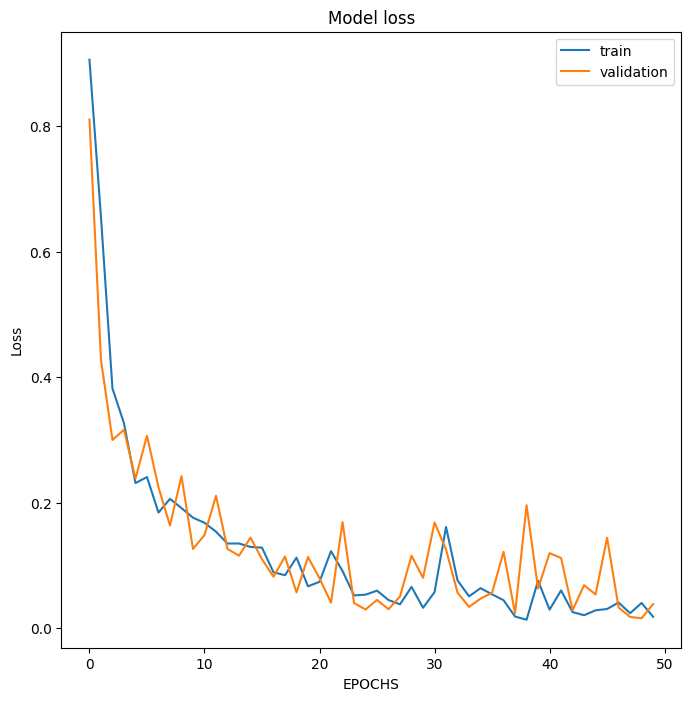

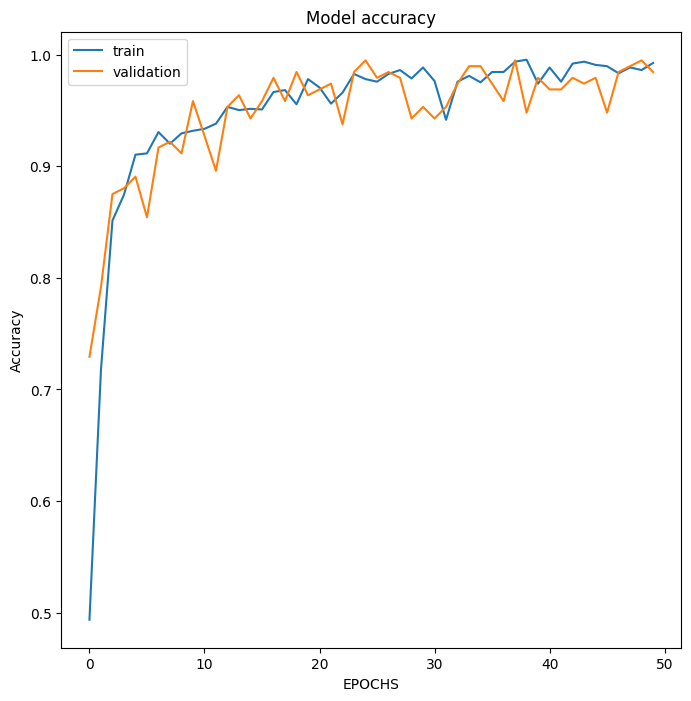

In [42]:
import pandas as pd
df_loss_acc = pd.DataFrame(history.history)
df_loss = df_loss_acc[['loss', 'val_loss']]
df_loss.rename(columns = {'loss': 'train', 'val_loss': 'validation'}, inplace=True)
df_acc = df_loss_acc[['accuracy', 'val_accuracy']]
df_acc.rename(columns = {'accuracy': 'train', 'val_accuracy': 'validation'}, inplace=True)
df_loss.plot(title = 'Model loss', figsize = (8,8)).set(xlabel='EPOCHS', ylabel='Loss')
df_acc.plot(title = 'Model accuracy', figsize = (8,8)).set(xlabel='EPOCHS', ylabel='Accuracy')


In [35]:
import numpy as np

### Run prediction on a sample

first image to predict
actual label: Potato___Late_blight
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
Potato___Late_blight


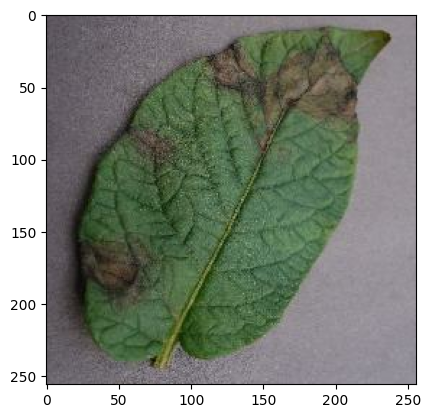

In [36]:
for images_batch, labels_batch in test_ds.take(1):

  first_image = images_batch[0].numpy().astype('uint8')
  first_label = labels_batch[0].numpy()

  print("first image to predict")
  plt.imshow(first_image)
  print("actual label:", class_names[first_label])

  batch_prediction = model.predict(images_batch)
  print(class_names[np.argmax(batch_prediction[0])])

In [44]:
# function to predict a class and the probability percentage
def predict(model, images):
  img_array = tf.keras.utils.img_to_array(images.numpy())
  img_array = tf.expand_dims(img_array, 0) # create a batch

  predictions = model.predict(img_array)

  predicted_class = class_names[np.argmax(predictions[0])]
  confidence = round(100 * (np.max(predictions[0])), 2)
  return predicted_class, confidence

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


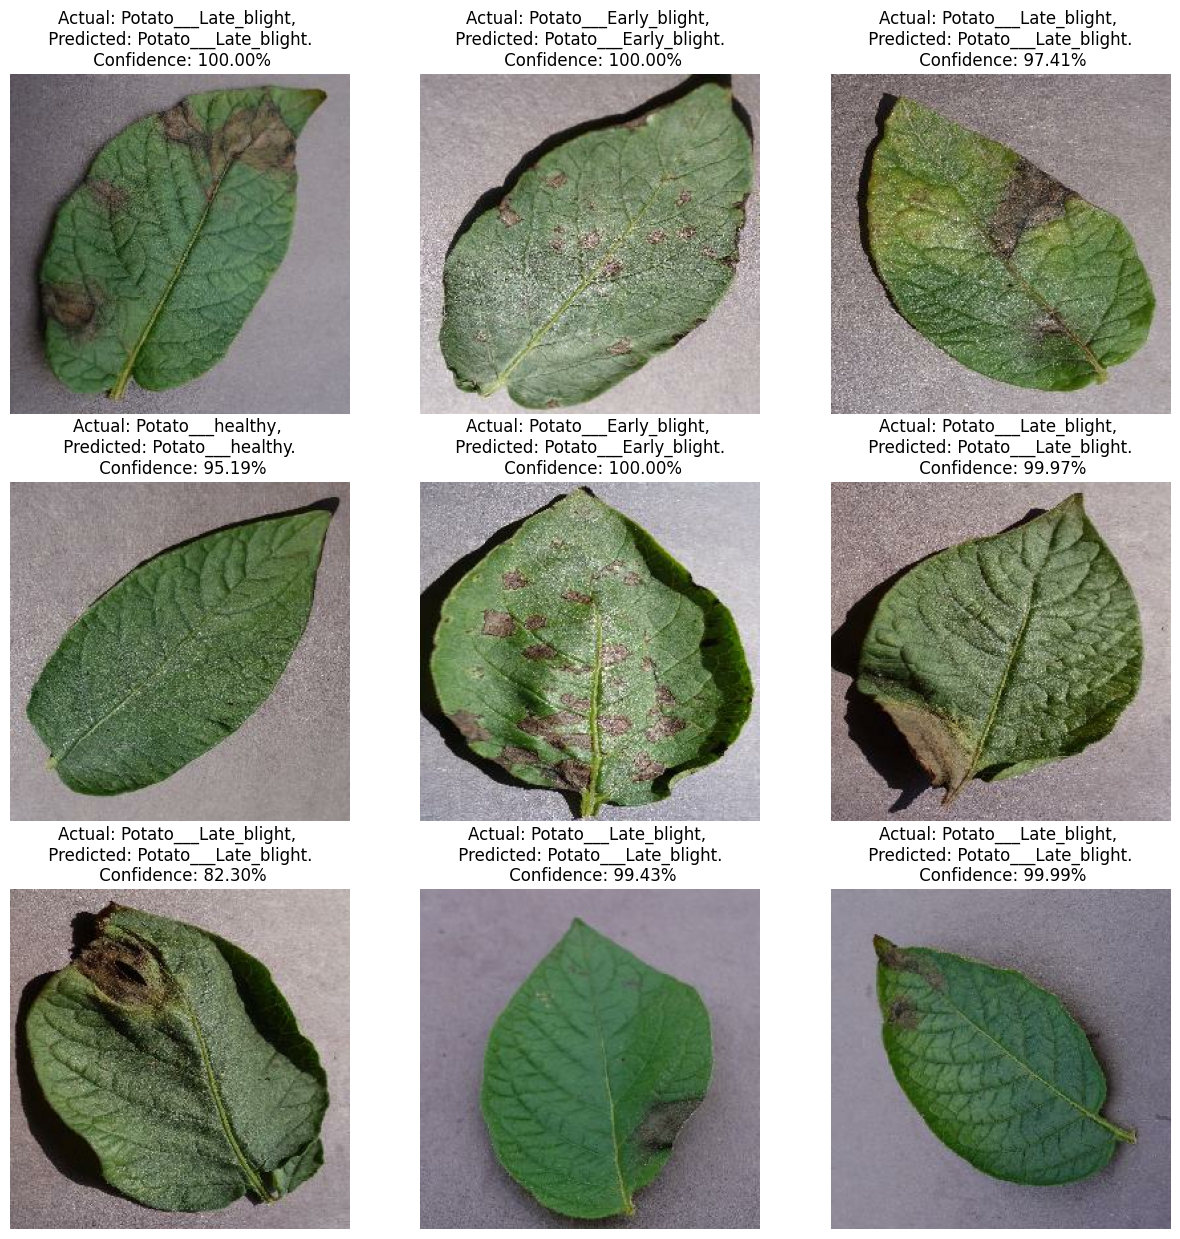

In [47]:
## predicting on multiple examples at once

plt.figure(figsize=(15, 15))
for images, labels in test_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype('uint8'))

    predicted_class, confidence = predict(model, images[i])
    actual_class = class_names[labels[i]]

    plt.title(f"Actual: {actual_class}, \n Predicted: {predicted_class}. \n Confidence: {confidence:.2f}%")

    plt.axis('off')

In [48]:
## save the model for deployment
model.save("/content/potatoes.h5")

In [39]:
model_version = 1
# model.save("/content/models/{model_version}")
model.export('/content/models')

Saved artifact at '/content/models'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  139483105914576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139483103067984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139482955704912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139482955705680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139482955704720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139482955703376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139482955706832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139482955706064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139482955707216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139482955707024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139482955703568

In [40]:
import os

model_version = 1
save_dir = f"/content/models/{model_version}"

os.makedirs(save_dir, exist_ok=True)
model.export(save_dir)


Saved artifact at '/content/models/1'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  139483105914576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139483103067984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139482955704912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139482955705680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139482955704720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139482955703376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139482955706832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139482955706064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139482955707216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139482955707024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1394829557035

In [41]:
!zip -r /content/model_v1.zip /content/models/1

from google.colab import files
files.download("/content/model_v1.zip")

  adding: content/models/1/ (stored 0%)
  adding: content/models/1/assets/ (stored 0%)
  adding: content/models/1/saved_model.pb (deflated 88%)
  adding: content/models/1/fingerprint.pb (stored 0%)
  adding: content/models/1/variables/ (stored 0%)
  adding: content/models/1/variables/variables.index (deflated 69%)
  adding: content/models/1/variables/variables.data-00000-of-00001 (deflated 8%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>